In [31]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

disease_name    = 'measles'
nuts_level      = 'nuts2'
min_date        = '2012-01-01'
max_date        = '2023-12-31'
split_trainval  = '2017-06-01'
split_valtest   = '2020-03-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 2
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0,
    prediction_mode     ='regression',
    temporal_frequency  ='m',
    weekly_time_index   = False ,
    daily_time_index    = False,
    monthly_time_index  = True
    )    

nuts_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

# bd = BaseLineDataLoaderManager(data_orchestrator)
# sd = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
# gl = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

In [32]:
from src.dataloading.airp import AirpConfig, AirpOrchestrator
from src.graphconstruction.airportgraph import AirportGraphOrchestrator, AirportGraphViewer

airpconfig                  = AirpConfig(nuts_orchestrator)
airp_orchestrator           = AirpOrchestrator(airpconfig, nuts_orchestrator).build_orchestration()

graph_orchestrator          = AirportGraphOrchestrator(airp_orchestrator)
graph_structure             = graph_orchestrator.generate_graphstructure('distance',  decay = 'boolean')
graph_previewer             = AirportGraphViewer(graph_orchestrator, airp_orchestrator.data_context,graph_structure)

graph_orchestrator.save_graphstructures(graph_structure, 'boolean_distance')

AirpConfig loaded succesfully ✓
AirpOrchestrator loaded succesfully ✓
boolean_distance saved


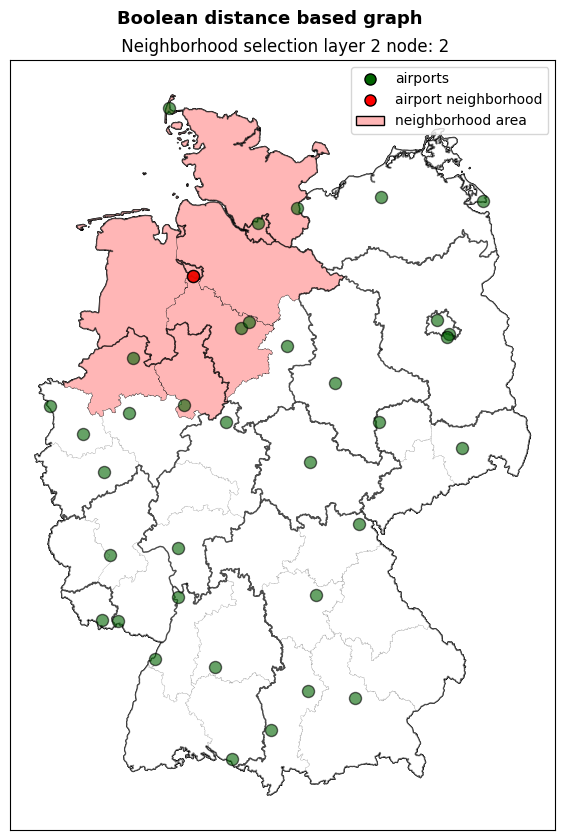

In [33]:
figure                      = (graph_previewer
                               .view(graphname = 'a', node_layer2=2)
                               .ticks.change_xticks([])
                               .ticks.change_yticks([])
                               .labels.change_suptitle('Boolean distance based graph', fontweight='bold', fontsize = 13)
                               .labels.set_suptitle_y(0.93)
                               )
figure.show()

### Risk score plots

Text(0.5, 1.0, 'Normalized risk score per airport')

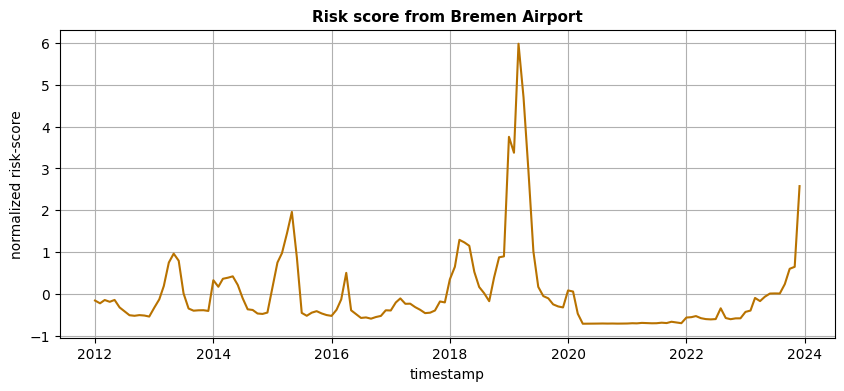

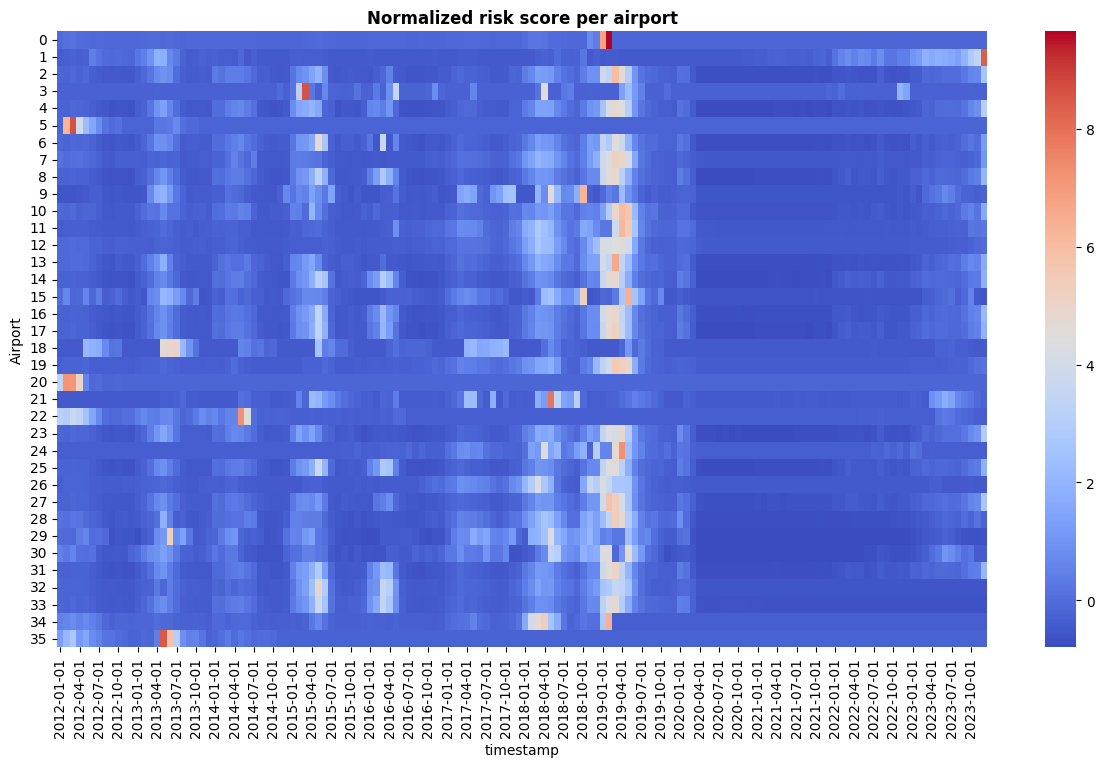

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

rki_blue_c  = '#B87200'

df      = airp_orchestrator.data_normalized.data 
df_node = df[df['id2'] == 2]

fig, ax = plt.subplots(1,1, figsize = (10,4))

sns.lineplot(df_node, x = 'timestamp', y = 'rs', color = rki_blue_c, ax = ax)
ax.set_ylabel('normalized risk-score')
ax.grid()
ax.set_title('Risk score from Bremen Airport', fontsize = 11, fontweight = 'bold')

dfc = df.copy()
dfc['timestamp'] = df['timestamp'].dt.date
df_wide = dfc.pivot_table(values = 'rs', columns = 'id2', index = 'timestamp')


fig, ax = plt.subplots(1,1, figsize = (15,8))
sns.heatmap(df_wide.transpose(), ax = ax, cmap ='coolwarm')
ax.set_ylabel('Airport')
ax.set_title('Normalized risk score per airport', fontweight = 'bold')


## DataLoading

In [35]:
from src.utils.textformatting import align
from src.graphconstruction.airportgraph.graphstructure import GraphStructure, GraphStructureError


import torch 
from dataclasses import dataclass
from typing import List



@dataclass
class NutsLayerGraphData:
    """
    Data for graph layer L1

    Parameters
    ----------
    x: torch.Tensor 
    edge_index: torch.Tensor 
    edge_weight: torch.Tensor 
    y: torch.Tensor
    """

    x:          torch.Tensor
    edge_index: torch.Tensor
    edge_weight:torch.Tensor
    y:          torch.Tensor
        
    def __post_init__(self):
        # validate input
        l, num_edges                        = self.edge_index.shape
        num_nodes_x, num_feat_x, num_seq_x  = self.x.shape
        num_nodes_y, num_horizon_y          = self.y.shape
        
        if l != 2:
            raise GraphStructureError('NutsLayerGraphData edge_index is expected to be of length 2')
        
        if num_edges != len(self.edge_weight):
            raise GraphStructureError(f'NutsLayerGraphData edge_index contains {num_edges} edges while edge_weight {len(self.edge_weight)} edges')     

        if num_nodes_x != num_nodes_y:
            raise GraphStructureError(f'NutsLayerGraphData x contains {num_nodes_x} nodes while y {num_nodes_y} nodes') 

        # TODO: Validate num_feat_x, num_seq_x, num_horizon_y against config                       
        
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"y={tuple(self.y.shape)}, "
            f"edge_index={tuple(self.edge_index.shape)}, "
            f"edge_weight={tuple(self.edge_weight.shape)}"
        )
        return f"{cls}({info})"
    
@dataclass
class AirportLayerGraphData:
    """
    Data for graph layer L2

    Parameters
    ----------
    x: torch.Tensor 
    edge_index: torch.Tensor 
    edge_weight: torch.Tensor
    """
    x:          torch.Tensor
    edge_index: torch.Tensor
    edge_weight:torch.Tensor
        
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"edge_index={tuple(self.edge_index.shape)}, "
            f"edge_weight={tuple(self.edge_weight.shape)}"
        )
        return f"{cls}({info})"    

    def __post_init__(self):
        # validate input
        l, num_edges                        = self.edge_index.shape
        num_nodes_x, num_feat = self.x.shape
        
        if l != 2:
            raise GraphStructureError('AirportLayerGraphData edge_index is expected to be of length 2')
        
        if num_edges != len(self.edge_weight):
            raise GraphStructureError(f'AirportLayerGraphData edge_index contains {num_edges} edges while edge_weight {len(self.edge_weight)} edges')     

        # TODO: Validate num_nodes_x, num_feat_x, num_seq_x, num_horizon_y against config of airport data
                
class NestedGraphData:
    """
    Data for graph layers L1 and L2 combined

    Parameters
    ----------
    nuts_layer:    NutsLayerGraphData
    airport_layer: AirportLayerGraphData
    """
    def __init__(self, 
                 nuts_layer:    NutsLayerGraphData, 
                 airport_layer: AirportLayerGraphData):
        
        # NUTS layer: L1
        self.x_l1           = nuts_layer.x 
        self.edge_index_l1  = nuts_layer.edge_index
        self.edge_weight_l1 = nuts_layer.edge_weight

        # Airport layer: L2
        self.x_l2           = airport_layer.x
        self.edge_index_l2  = airport_layer.edge_index 
        self.edge_weight_l2 = airport_layer.edge_weight 

        # Targets -> for L1
        self.y              = nuts_layer.y

        # based on airport graph
        num_airports      = self.edge_index_l2[0].max().item() + 1
        num_nodes_l2      = self.edge_index_l2[1].max().item() + 1       
        num_nodes_l1      = max(self.edge_index_l1[0].max().item(),self.edge_index_l1[1].max().item()) + 1

        if num_nodes_l1 != num_nodes_l2:
            raise GraphStructureError(f'num nodes found in L2: {num_nodes_l2} and in L1: {num_nodes_l1}')

    def to(self, device):
        """Move all tensors to device"""
        device = torch.device(device)   # Normalize device string/object
  
        self.x_l1           = self.x_l1.to(device)
        self.edge_index_l1  = self.edge_index_l1.to(device)
        self.edge_weight_l1 =self.edge_weight_l1.to(device)

        self.x_l2           = self.x_l2.to(device)  
        self.edge_index_l2  = self.edge_index_l2.to(device)
        self.edge_weight_l2 = self.edge_weight_l2.to(device)        

        self.y              = self.y.to(device)
        return self

    def cpu(self):
        """Convenience method to move to CPU"""
        return self.to('cpu')

    def cuda(self, device=None):
        """Convenience method to move to CUDA"""
        if device is None:
            return self.to('cuda')
        return self.to(f'cuda:{device}')

    @property
    def device(self):
        """Get current device of the data (from first layer's x tensor)"""
        return self.x_l1.device

    def __repr__(self):
        lines = f'<{self.__class__.__name__}(L1, L2)>'
        return lines

    def __str__(self):
        indent = 4
        keys   = ['edge_weight', 'edge_index']
        width  = max(len(k) for k in keys) + 1
        # Build output
        lines = [f'<{self.__class__.__name__}(']

        first_header = align('L1',"NUTS", 1)
        second_header = align('L2',"Airports", 1)

        lines.append(first_header)
        lines.append(" "*indent+"_"*len(first_header))
        lines.append(align('x', tuple(self.x_l1.shape), width))
        lines.append(align('edge_index', tuple(self.edge_index_l1.shape), width))        
        lines.append(align('edge_weight', tuple(self.edge_weight_l1.shape), width)) 
        lines.append('')         
        lines.append(second_header)     
        lines.append(" "*indent+"_"*len(second_header))          
        lines.append(align('x', tuple(self.x_l2.shape), width))
        lines.append(align('edge_index', tuple(self.edge_index_l2.shape), width))        
        lines.append(align('edge_weight', tuple(self.edge_weight_l2.shape), width))         
        lines.append(')>')
        
        return '\n'.join(lines)
    
class GraphDataSet:
    """
    A list of Data objects, for now limited to NestedGraphData objects

    Parameters
    ----------
    data_list: List[NestedGraphData]
    """    
    def __init__(self, data_list: List[NestedGraphData]):
        self.data_list  = data_list
        self._data_class= data_list[0].__class__.__name__

    def __iter__(self):
        return iter(self.data_list)
    
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx: int):
        return self.data_list[idx]                   

    def __repr__(self):
        return self.__str__()

    def __str__(self) -> str:
        keys   = ['datapoints','dataclass']
        width  = max(len(k) for k in keys) + 1
        # Build output
        lines = [f'<{self.__class__.__name__}(\n']
        lines.append(align('datapoints',self.__len__(),width,newline=True))
        lines.append(align('dataclass',self._data_class, width))
        lines.append(')>')
        
        return ''.join(lines)

In [36]:
@dataclass
class DeepDataLoaderCollection:
    """ 
    """
    train:              'GraphDataSet'
    val:                'GraphDataSet'   
    test:               'GraphDataSet'
    main:               'GraphDataSet'

    def __repr__(self):
        return (f"<DeepDataLoaderCollection(train, val, test, main)>") 

In [37]:
import torch
import pandas as pd
import numpy as np 
import os
from typing import List, Tuple, Optional, Union, Literal, TYPE_CHECKING
from dataclasses import dataclass
from src.graphconstruction.airportgraph.graphstructure import GraphStructure
from tqdm import tqdm
from src.utils.textformatting import error_emoji, checkmark

if TYPE_CHECKING:
    from src.dataloading import DataOrchestrator
    from src.dataloading.airp import AirpOrchestrator

@dataclass
class GraphDataCollection:
    """ 
    Stores all DataSets for deep-graph-dataloaders

    Parameters
    ----------
    train: 'GraphDataSet

    val: 'GraphDataSet

    test: 'GraphDataSet

    main: 'GraphDataSet

    Downstream
    --------
    """
    train:              'GraphDataSet'
    val:                'GraphDataSet'   
    test:               'GraphDataSet'
    main:               'GraphDataSet'

    def __repr__(self):
        return (f"<GraphDataLoaderCollection(train, val, test, main)>") 

class NestedGraphDataLoaderManager:
    """
    """
    def __init__(self, 
                 epidata_orchestrator: 'DataOrchestrator',
                 airpdata_orchestrator: 'AirpOrchestrator'):
        
        self.epidata_orchestrator       = epidata_orchestrator
        self.airpdata_orchestrator      = airpdata_orchestrator

        self.epidata                         = epidata_orchestrator.data_final.data
        self.airpdata                        = airpdata_orchestrator.data_normalized.data
        
        self.nuts_graph_mode: Optional[Literal['static','dynamic']] = None
            
    def retrieve_static_graphs(self, graphname_l2: str, graphname_l3: str, graphdirectory: str = 'data/graphs') -> 'NestedGraphDataLoaderManager':
        """
        """
    
        graphpath_l2= os.path.join(graphdirectory, 'airports', graphname_l2, graphname_l2)
        l2_i, l2_w  = torch.load(graphpath_l2 + '_edge_index.pt', weights_only = False), torch.load(graphpath_l2 + '_edge_weight.pt', weights_only = False)
        l2_graph    = GraphStructure(l2_i, l2_w)
           

        graphpath_l3= os.path.join(graphdirectory, self.epidata_orchestrator.config.nuts_level, graphname_l3, graphname_l3)
        l3_i, l3_w  = torch.load(graphpath_l3 + '_edge_index.pt', weights_only = False), torch.load(graphpath_l3 + '_edge_weight.pt', weights_only = False)
        l3_graph    = GraphStructure(l3_i, l3_w)


        self.graph_l2      = l2_graph
        self.graph_l3      = l3_graph
       
        return self

    def construct_dataloaders(self):
        """
        creates the actual dataloaders
        """
        epidata, airpdata                   = self._align_nestedx(align_to_t0=True)
        X1,y,X2                             = self._construct_XXy(epidata, airpdata)
        main_dataloader                     = self._construct_main_dataloader(X1, y, X2)
        self.dataloader_collection          = self._split_dataloader(main_dataloader = main_dataloader)
        return self     

    def _construct_XXy(self, 
                      epidata: pd.DataFrame,
                      airpdata: pd.DataFrame):
        """      
        """
        # ========= epidata ========== #
        dfc                 = epidata.copy()
        feature_arrays      = []
        target_arrays       = []
        target_timepoints   = dfc['timestamp'].unique().tolist()

        feature_cols        = self.epidata_orchestrator.column_registration.get_by_type('feature')
        split_cols          = self.epidata_orchestrator.column_registration.get_by_type('split')
        target_cols         = self.epidata_orchestrator.column_registration.get_by_type('target')          

        # Time splits based on target timestamp
        time_splits         = dfc[['timestamp'] + split_cols].drop_duplicates().reset_index(drop = True)
        self.time_splits    = time_splits

        # create feature_arrays:
        # a list of np.arrays. Each array is of shape [num_timestamp, num_nodes]
        # which are merged together into a list of an array per feature.
        for feat in feature_cols:
            dtype = dfc[feat].dtype
            # Pivot from long to wide: rows=time, columns=nodes, values=feature
            pivoted = dfc.pivot(index=['timestamp'], columns='node', values=feat).reset_index(drop = True)

            # convert to numeric
            pivoted = pivoted.apply(pd.to_numeric, errors='coerce')

            # Convert to numpy float array, replace NaNs with 0
            arr = pivoted.values
            if str(dtype).startswith('int'):
                arr = arr.astype(np.int32)
            else:
                arr = arr.astype(np.float32)             # force float32 dtype

            feature_arrays.append(arr)
        
        # create target_arrays using the same approach:
        # a list of np.arrays. Each array is of shape [num_timestamp, num_nodes]
        # which are merged together into a list of an array per target column (per prediction horizon).
        for target in target_cols:
            for dfc_col in dfc.columns:
                
                if target in dfc_col and dfc_col not in feature_cols:
                    dtype = dfc[dfc_col].dtype
                    # Pivot from long to wide: rows=time, columns=nodes, values=feature
                    pivoted = dfc.pivot(index=['timestamp'], columns='node', values=dfc_col).reset_index(drop = True)

                    # convert to numeric
                    pivoted = pivoted.apply(pd.to_numeric, errors='coerce')
                    
                    # Convert to numpy float array, replace NaNs with 0
                    arr = pivoted.values
                    if str(dtype).startswith('int'):
                        arr = arr.astype(np.int32)
                    else:
                        arr = arr.astype(np.float32)   
                    target_arrays.append(arr)
        
        # ======= layer 2 ========= #
        dfc     = airpdata.copy()
        dfc     = dfc[dfc['timestamp_shifted'].isin(target_timepoints)]
        pivoted = dfc.pivot(index=['timestamp'], columns='id2', values='rs').reset_index(drop = True)
        pivoted = pivoted.apply(pd.to_numeric, errors='coerce')
        arr     = pivoted.values
        arr     = arr.astype(np.float32)           


        # now reshape the lists of arrays into 3d arrays
        X1_np = np.stack(feature_arrays, axis=-1) # [num_timestamps, num_nodes, num_features]
        y1_np = np.stack(target_arrays,  axis=-1) # [num_timestamps, num_nodes, horizon_size]
        X2_np = np.stack(arr)

        # convert 3d arrays to tensors
        X1_tensor = torch.tensor(X1_np, dtype=torch.float) 
        y1_tensor = torch.tensor(y1_np, dtype=torch.float)
        X2_tensor = torch.tensor(X2_np, dtype=torch.float)
        return X1_tensor, y1_tensor, X2_tensor

    def _align_nestedx(self, align_to_t0: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        align_to_t0 means align with input
        with the default settings, that suggest that 
        the flights of 2012-01 should be merged to
        whatever the first target timestamp is.
        The shift_int should thus be equal to 
        horizon_leadtime
        """
        if self.epidata_orchestrator.config.temporal_frequency != 'm':
            raise ValueError(f'currently only monthly samplign is allowed when merging flights and epi data!')

        if align_to_t0:
            time_shift_flights_data = self.epidata_orchestrator.config.horizon_leadtime

            time_shifted_airp_data                      = self.airpdata.copy()
            time_shifted_airp_data['timestamp_shifted'] = time_shifted_airp_data['timestamp'] + pd.DateOffset(months = time_shift_flights_data)

            return (self.epidata, time_shifted_airp_data)
        
        else:
            raise ValueError(f'currently only align_to_t0 == True is handled')

    def _construct_main_dataloader(self, 
                                   X3: torch.Tensor,
                                   y3: torch.Tensor, 
                                   X2: torch.Tensor):
        """
        """
        dataset = []
        T       = X3.shape[0]  # Total number of timesteps

        # Calculate maximum valid start position
        # Need: start + periods + prediction_horizon - 1 < T
        max_start       = T - self.epidata_orchestrator.config.horizon_leadtime - (self.epidata_orchestrator.config.horizon_size - 1) - (self.epidata_orchestrator.config.sequence_length - 1)
        self.max_start  = max_start

        if max_start <= 0:
            raise ValueError(f"Not enough data: T={T}, periods={self.epidata_orchestrator.config.sequence_length}"
                            f"Need at least {self.epidata_orchestrator.config.sequence_length} timesteps.")

        for t_idx, start in enumerate(range(max_start)):
            # Input window: periods consecutive timesteps
            x3_seq = X3[start : start + self.epidata_orchestrator.config.sequence_length]  # shape [periods, nodes, features]
            y3_seq = y3[start + self.epidata_orchestrator.config.sequence_length - 1]
            x2_seq = X2[start: start + self.epidata_orchestrator.config.sequence_length]

            graphdata_layer3 = NutsLayerGraphData(x3_seq.clone().detach().float().permute(1, 2, 0), self.graph_l3.edge_index, self.graph_l3.edge_weight, y3_seq)
            graphdata_layer2 = AirportLayerGraphData(x2_seq.clone().detach().float().permute(1, 0), self.graph_l2.edge_index, self.graph_l2.edge_weight)           
            

            data = NestedGraphData(
                nuts_layer=graphdata_layer3,
                airport_layer=graphdata_layer2
            )
            dataset.append(data)

        return GraphDataSet(dataset)

    def _split_dataloader(self, 
                          main_dataloader: GraphDataSet) -> DeepDataLoaderCollection:
        """
        Splits main dataloader into those for train/val/test
        """        

        train_idx = list(self.time_splits[self.time_splits['train']].index)
        val_idx   = list(self.time_splits[self.time_splits['val']].index)
        test_idx  = list(self.time_splits[self.time_splits['test']].index)

        dataloader_train = GraphDataSet([main_dataloader[tt] for tt in train_idx])
        dataloader_val   = GraphDataSet([main_dataloader[tt] for tt in val_idx])
        dataloader_test  = GraphDataSet([main_dataloader[tt] for tt in test_idx if tt < self.max_start])        
        
        return DeepDataLoaderCollection(
            train = dataloader_train,
            val   = dataloader_val,
            test  = dataloader_test,
            main  = main_dataloader
        )

    def __repr__(self) -> str:
        
        representation = "<NestedGraphDataLoaderManager("

        if hasattr(self, 'graph_l2'):
            representation += f'graph layer 2 {checkmark}, '
        if hasattr(self, 'graph_l3'):
            representation += f'graph layer 3 {checkmark}'     

        return representation +")>"

    def __str__(self)->str:
        # Calculate width
        all_keys = ['graph layer 2', 'graph layer 3']

        max_width = max([len(key) for key in all_keys]) + 1

        lines = ["<NestedGraphDataLoaderManager(\n"] 
        
        if hasattr(self, 'graph_l2'):
            lines.append(align('graph layer 2', checkmark, max_width, newline=True))
        if hasattr(self, 'graph_l3'):
            lines.append(align('graph layer 3', checkmark, max_width, newline=True))

        representation = ''.join(lines) +")>"

        return representation

In [38]:
nested_dataloader = NestedGraphDataLoaderManager(nuts_orchestrator, airp_orchestrator)
nested_dataloader.retrieve_static_graphs('boolean_distance','identity_graph').construct_dataloaders()

<NestedGraphDataLoaderManager(graph layer 2 ✓, graph layer 3 ✓)>

# Now I have smth like a nested graph dataloader

# Modelling

In [39]:
train_loader = nested_dataloader.dataloader_collection.train
val_loader = nested_dataloader.dataloader_collection.val
test_loader = nested_dataloader.dataloader_collection.test

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.utils import scatter

class SpatialMeaslesGNN(nn.Module):
    """Pure spatial GNN for NUTS2-level predictions"""
    def __init__(self, hidden_dim=128, num_gnn_layers=3, dropout=0.2):
        super().__init__()
        
        # GNN layers for NUTS2 regions
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        # First layer: input features -> hidden
        self.convs.append(GCNConv(3, hidden_dim))
        self.norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Hidden layers
        for _ in range(num_gnn_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Airport encoder
        self.airport_encoder = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # Attention-based fusion of region + airport info
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        
        # Predictor
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.dropout = dropout
    
    def forward(self, x_l1, edge_index_l1, edge_weight_l1, 
                x_l2, edge_index_l2, edge_weight_l2):
        
        if x_l1.dim() == 3:
            x_l1 = x_l1.squeeze(-1)
        
        # Process NUTS2 spatial graph with residual connections
        h = x_l1
        for i, (conv, norm) in enumerate(zip(self.convs, self.norms)):
            h_new = conv(h, edge_index_l1, edge_weight_l1)
            h_new = norm(h_new)
            h_new = F.relu(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            
            # Residual connection
            if h.shape == h_new.shape:
                h = h + h_new
            else:
                h = h_new
        
        # Encode airports
        h_airport = self.airport_encoder(x_l2)
        
        # Aggregate airport -> NUTS2
        airport_messages = h_airport[edge_index_l2[0]]
        if edge_weight_l2 is not None:
            airport_messages = airport_messages * edge_weight_l2.unsqueeze(-1)
        
        h_airport_agg = scatter(
            airport_messages,
            edge_index_l2[1],
            dim=0,
            dim_size=x_l1.shape[0],  # 38 NUTS2 regions
            reduce='mean'
        )
        
        # Learned fusion of region + airport features
        h_concat = torch.cat([h, h_airport_agg], dim=-1)
        gate = self.fusion(h_concat)  # Attention weight
        h_fused = gate * h + (1 - gate) * h_airport_agg
        
        # Final features: original + gated
        h_final = torch.cat([h, h_fused], dim=-1)
        
        # Predict
        out = self.predictor(h_final).squeeze(-1)
        return F.softplus(out)  # Non-negative


class FocalLoss(nn.Module):
    """Focal loss - focuses on hard examples (non-zeros)"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, pred, target):
        # Standard MSE
        mse = (pred - target) ** 2
        
        # Focal weighting: up-weight hard examples
        # When pred is far from target, weight is high
        focal_weight = torch.abs(pred - target) ** self.gamma
        
        # Class balancing: up-weight non-zeros
        # alpha=0.25 means 75% weight on non-zeros
        is_nonzero = (target > 0).float()
        class_weight = is_nonzero * (1 - self.alpha) + (1 - is_nonzero) * self.alpha
        
        loss = mse * focal_weight * class_weight
        return loss.mean()


def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch in dataloader:
        optimizer.zero_grad()
        
        pred = model(
            batch.x_l1.to(device),
            batch.edge_index_l1.to(device),
            batch.edge_weight_l1.to(device) if batch.edge_weight_l1 is not None else None,
            batch.x_l2.to(device),
            batch.edge_index_l2.to(device),
            batch.edge_weight_l2.to(device) if batch.edge_weight_l2 is not None else None
        )
        
        y = batch.y.to(device).squeeze().float()
        
        loss = criterion(pred, y)
        
        if torch.isnan(loss):
            print(f"NaN loss, skipping batch")
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / max(num_batches, 1)


def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch in dataloader:
            pred = model(
                batch.x_l1.to(device),
                batch.edge_index_l1.to(device),
                batch.edge_weight_l1.to(device) if batch.edge_weight_l1 is not None else None,
                batch.x_l2.to(device),
                batch.edge_index_l2.to(device),
                batch.edge_weight_l2.to(device) if batch.edge_weight_l2 is not None else None
            )
            all_preds.append(pred.cpu())
            all_targets.append(batch.y.squeeze().cpu())
    
    preds = torch.cat(all_preds)
    targets = torch.cat(all_targets).float()
    preds_int = torch.round(preds).clamp(min=0).long()
    
    # Overall metrics
    mae = (preds_int - targets).abs().float().mean()
    rmse = torch.sqrt(((preds - targets) ** 2).mean())
    
    # Breakdown by zeros vs non-zeros
    mask_zero = targets == 0
    mask_nonzero = targets > 0
    
    results = {
        'mae': mae.item(),
        'rmse': rmse.item(),
        'pred_mean': preds.mean().item(),
        'pred_std': preds.std().item(),
        'n_total': len(targets),
        'n_nonzero_actual': mask_nonzero.sum().item(),
        'n_nonzero_pred': (preds_int > 0).sum().item(),
    }
    
    if mask_zero.sum() > 0:
        results['zero_accuracy'] = ((preds_int == 0) & mask_zero).sum().item() / mask_zero.sum().item()
        results['mae_zero'] = preds_int[mask_zero].float().mean().item()
    
    if mask_nonzero.sum() > 0:
        results['detection_rate'] = (preds_int[mask_nonzero] > 0).sum().item() / mask_nonzero.sum().item()
        results['mae_nonzero'] = (preds_int[mask_nonzero] - targets[mask_nonzero]).abs().float().mean().item()
        
        if len(preds[mask_nonzero]) > 1:
            corr = torch.corrcoef(torch.stack([preds[mask_nonzero], targets[mask_nonzero]]))[0, 1]
            results['corr_nonzero'] = corr.item() if not torch.isnan(corr) else 0.0
    
    return results


# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SpatialMeaslesGNN(hidden_dim=128, num_gnn_layers=3, dropout=0.2).to(device)

# Try focal loss (focuses on non-zeros) or simple MSE
criterion = FocalLoss(alpha=0.8, gamma=2.0).to(device='cuda')  # 80% weight on non-zeros
# Alternative: criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15, verbose=True
)

print(f"Training spatial GNN for NUTS2 (n={38})...")
best_mae = float('inf')

for epoch in range(200):
    train_epoch(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device)
    val_results = evaluate(model, val_loader, device)
    
    if epoch % 10 == 0:
        print(f"\nEpoch {epoch}:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val MAE: {val_results['mae']:.3f}, RMSE: {val_results['rmse']:.3f}")
        print(f"  Pred: {val_results['n_nonzero_pred']}/{val_results['n_total']} non-zero (mean={val_results['pred_mean']:.3f})")
        print(f"  Actual: {val_results['n_nonzero_actual']}/{val_results['n_total']} non-zero")
        
        if 'detection_rate' in val_results:
            print(f"  Detection rate: {val_results['detection_rate']*100:.1f}%")
            print(f"  MAE (non-zero): {val_results['mae_nonzero']:.3f}")
            print(f"  Correlation: {val_results.get('corr_nonzero', 0):.3f}")
        
        if 'zero_accuracy' in val_results:
            print(f"  Zero accuracy: {val_results['zero_accuracy']*100:.1f}%")
    
    if val_results['mae'] < best_mae:
        best_mae = val_results['mae']
        torch.save(model.state_dict(), 'best_nuts2_model.pt')
    
    scheduler.step(val_results['mae'])

# Test
model.load_state_dict(torch.load('best_nuts2_model.pt', weights_only=True))
test_results = evaluate(model, test_loader, device)

print("\n" + "="*60)
print("TEST SET RESULTS (NUTS2)")
print("="*60)
for k, v in test_results.items():
    print(f"{k}: {v}")

Training spatial GNN for NUTS2 (n=38)...

Epoch 0:
  Train Loss: 6.2571
  Val MAE: 3.024, RMSE: 4.116
  Pred: 1254/1254 non-zero (mean=3.240)
  Actual: 369/1254 non-zero
  Detection rate: 100.0%
  MAE (non-zero): 3.092
  Correlation: 0.111
  Zero accuracy: 0.0%

Epoch 10:
  Train Loss: 6.2571
  Val MAE: 6.756, RMSE: 7.263
  Pred: 1254/1254 non-zero (mean=7.352)
  Actual: 369/1254 non-zero
  Detection rate: 100.0%
  MAE (non-zero): 5.864
  Correlation: 0.134
  Zero accuracy: 0.0%

Epoch 20:
  Train Loss: 6.2571
  Val MAE: 10.945, RMSE: 14.390
  Pred: 1254/1254 non-zero (mean=11.593)
  Actual: 369/1254 non-zero
  Detection rate: 100.0%
  MAE (non-zero): 10.507
  Correlation: 0.124
  Zero accuracy: 0.0%

Epoch 30:
  Train Loss: 6.2571
  Val MAE: 12.195, RMSE: 16.167
  Pred: 1054/1254 non-zero (mean=12.423)
  Actual: 369/1254 non-zero
  Detection rate: 76.7%
  MAE (non-zero): 10.962
  Correlation: 0.036
  Zero accuracy: 12.9%

Epoch 40:
  Train Loss: 6.2571
  Val MAE: 4.886, RMSE: 8.337
  